In [1]:
#Importing all the necessary libraries and modules
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima.arima import auto_arima
from pmdarima.arima import OCSBTest 
from statsmodels.tsa.arima_model import ARIMA
from arch import arch_model
import seaborn as sns
import yfinance
import warnings
warnings.filterwarnings("ignore")
sns.set()

### We will work on the NIFTY 50 Stock Index

In [2]:
# Importing the raw NIFTY 50 data using yfinance 
raw_nifty_data = yfinance.download (tickers = "^NSEI", #The time series we are interested in - (in our case, this is NIFTY 50 )
                              start = "2007-09-17", #The starting date of our data set
                              end = "2026-04-30", #The ending date of our data set (at the time of upload, this is the current date)
                              interval = "1d", #The distance in time between two recorded observations. Since we're using daily closing prices, we set it equal to "1d", which indicates 1 day. 
                              group_by = 'ticker', #The way we want to group the scraped data. Usually we want it to be "ticker", so that we have all the information about a time series in 1 variable.
                              auto_adjust = True, #Automatically adjuss the closing prices for each period. 
                              threads = True) #Whether to use threads for mass downloading. 

[*********************100%***********************]  1 of 1 completed


In [3]:
raw_nifty_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4565 entries, 2007-09-17 to 2026-04-29
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (^NSEI, Open)    4565 non-null   float64
 1   (^NSEI, High)    4565 non-null   float64
 2   (^NSEI, Low)     4565 non-null   float64
 3   (^NSEI, Close)   4565 non-null   float64
 4   (^NSEI, Volume)  4565 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 214.0 KB


In [4]:
raw_nifty_data.head()

Ticker            ^NSEI                                              
Price              Open         High          Low        Close Volume
Date                                                                 
2007-09-17  4518.450195  4549.049805  4482.850098  4494.649902      0
2007-09-18  4494.100098  4551.799805  4481.549805  4546.200195      0
2007-09-19  4550.250000  4739.000000  4550.250000  4732.350098      0
2007-09-20  4734.850098  4760.850098  4721.149902  4747.549805      0
2007-09-21  4752.950195  4855.700195  4733.700195  4837.549805      0

`Saving Our Raw Data into csv for later use`

In [5]:
raw_nifty_data.to_csv("OHLCV_nifty.csv")

In [6]:
# Making a copy of the raw data for all the manipulation
nifty_df = raw_nifty_data.copy()

In [7]:
print(nifty_df.shape)
print(nifty_df.describe())

(4565, 5)
Ticker         ^NSEI                                                        
Price           Open          High           Low         Close        Volume
count    4565.000000   4565.000000   4565.000000   4565.000000  4.565000e+03
mean    11156.200583  11214.924116  11082.173118  11149.965669  2.150916e+05
std      6533.541101   6553.472008   6507.892713   6531.328067  2.062892e+05
min      2553.600098   2585.300049   2252.750000   2524.199951  0.000000e+00
25%      5705.000000   5739.450195   5662.750000   5699.100098  0.000000e+00
50%      8805.700195   8838.450195   8750.500000   8780.349609  1.916000e+05
75%     16043.799805  16150.500000  15927.299805  16058.299805  2.988000e+05
max     26333.699219  26373.199219  26210.050781  26328.550781  1.811000e+06


In [8]:
nifty_df.columns = nifty_df.columns.droplevel(0)

In [9]:
nifty_df.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2007-09-17,4518.450195,4549.049805,4482.850098,4494.649902,0
2007-09-18,4494.100098,4551.799805,4481.549805,4546.200195,0
2007-09-19,4550.250000,4739.000000,4550.250000,4732.350098,0
2007-09-20,4734.850098,4760.850098,4721.149902,4747.549805,0
2007-09-21,4752.950195,4855.700195,4733.700195,4837.549805,0


In [10]:
# Data Cleaning and Preprocessing
nifty_df['price'] = nifty_df['Close']

In [11]:
# Delete other columns which are not necessary
del nifty_df['Open']
del nifty_df['Close']
del nifty_df['High']
del nifty_df['Low']
del nifty_df['Volume']

In [12]:
# Now we only have closing price with column name as price
nifty_df.head()

Price,price
Date,
2007-09-17,4494.649902
2007-09-18,4546.200195
2007-09-19,4732.350098
2007-09-20,4747.549805
2007-09-21,4837.549805


In [13]:
nifty_df = nifty_df.asfreq("B") # business days
nifty_df = nifty_df.ffill() # forward fill to remove the NaN prices

In [14]:
nifty_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4858 entries, 2007-09-17 to 2026-04-29
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   4858 non-null   float64
dtypes: float64(1)
memory usage: 75.9 KB


In [15]:
# Forming Log Returns 
nifty_df['returns'] = np.log(nifty_df['price']/ nifty_df['price'].shift(1))*100

`Cool We are done with our CLeaning and Pre Processing`

In [16]:
# Let us Train- test split the data with 80-20 form
mark = int(len(nifty_df)*0.8)
nifty_train = nifty_df.iloc[:mark]
nifty_test = nifty_df.iloc[mark:]

In [17]:
print(f'Shape of training data -> {nifty_train.shape}')
print(f'Shape of testing data -> {nifty_test.shape}')

Shape of training data -> (3886, 2)
Shape of testing data -> (972, 2)


#### Plotting The Data 

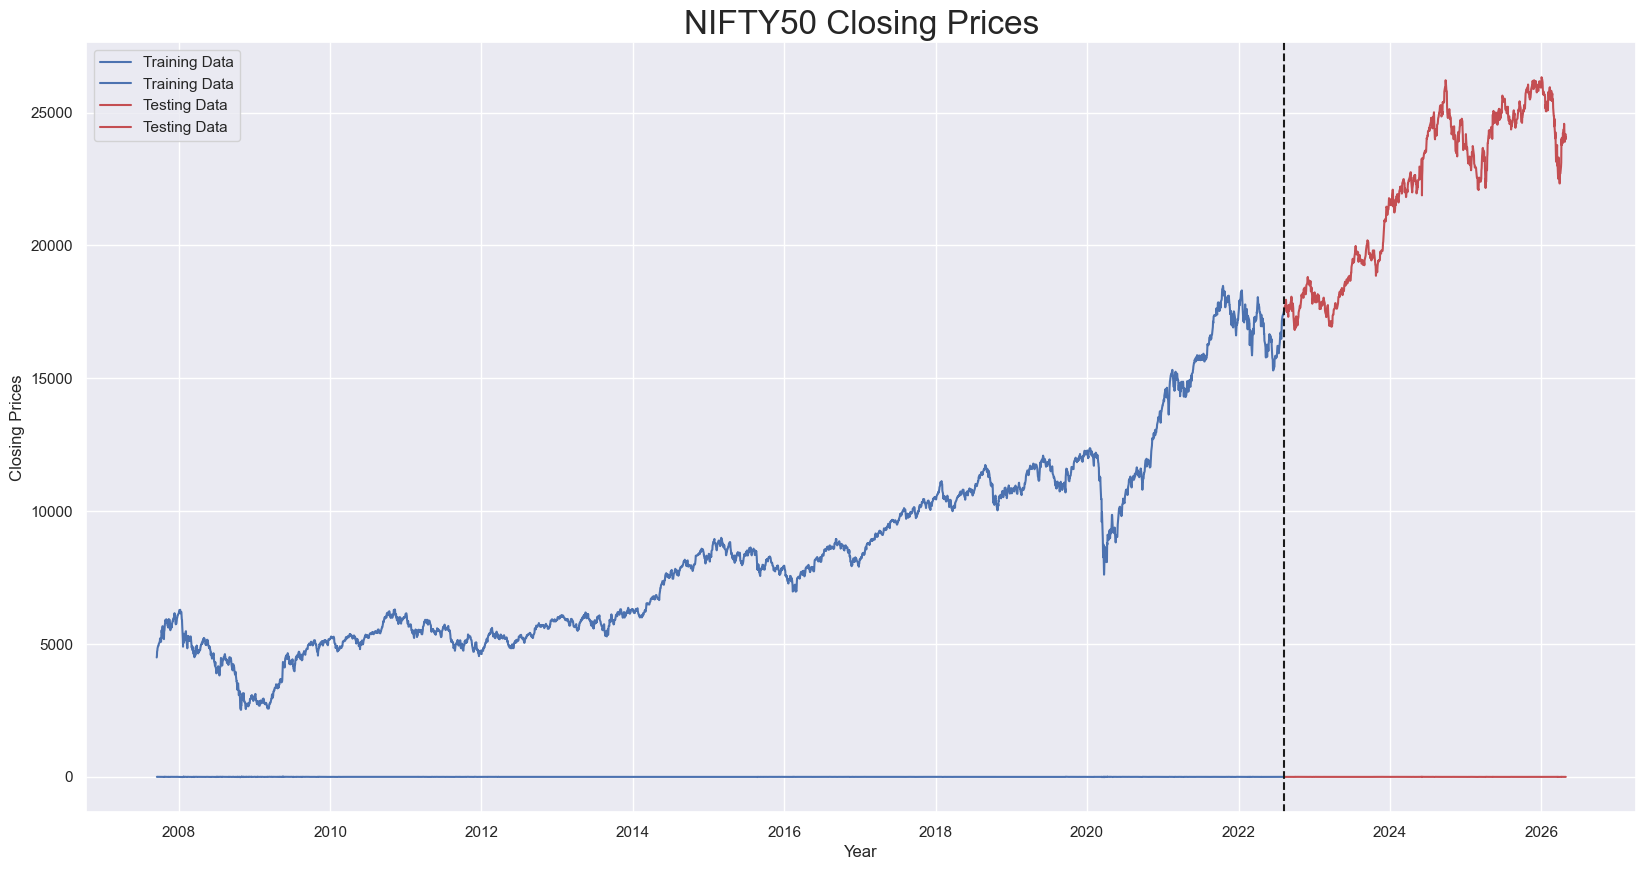

In [18]:
plt.figure(figsize=(20,10))
plt.plot(nifty_train,color='b',label='Training Data')
plt.plot(nifty_test,color='r',label='Testing Data')
plt.axvline(nifty_train.index[-1],linestyle="--",color='k')
plt.legend()
plt.title("NIFTY50 Closing Prices",size=24)
plt.xlabel("Year")
plt.ylabel("Closing Prices")
plt.show()

In [19]:
# Summary Statistics
print(nifty_df.describe())

Price         price      returns
count   4858.000000  4857.000000
mean   11117.077396     0.034642
std     6523.280783     1.263510
min     2524.199951   -13.903756
25%     5694.649902    -0.479922
50%     8771.900391     0.000000
75%    15935.037842     0.604950
max    26328.550781    16.334315


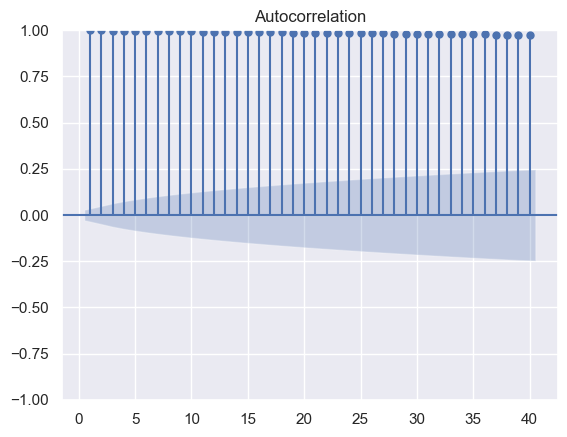

In [21]:
# Plotting ACF and PACF On Closing Prices
sgt.plot_acf(nifty_df.price , zero=False,lags=40)
plt.show()

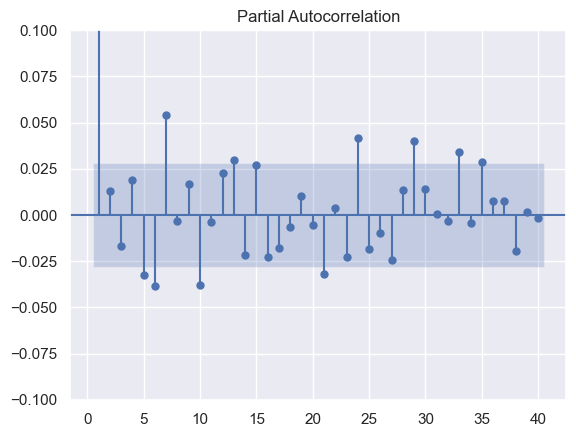

In [22]:
sgt.plot_pacf(nifty_df.price , zero=False,lags=40, alpha=0.05, method=('ols'))
plt.ylim(-.1,.1)
plt.show()

`FROM ACF, we can see that the Prices are Non- Stationary`                                                                 
`To confirm this -> We run Augmented Dickey Fuller Test`

In [25]:
t_stats, p_value , *other  = sts.adfuller(nifty_df.price)

In [26]:
print(f'T-Statistic = {t_stats} \n P-Value = {p_value}')

T-Statistic = 0.6044540417498322 
 P-Value = 0.9877249006536756


`Since p value > 0.05 Thus we cannot reject the Null Hyppothesis -> Closing Prices is Non Stationary`

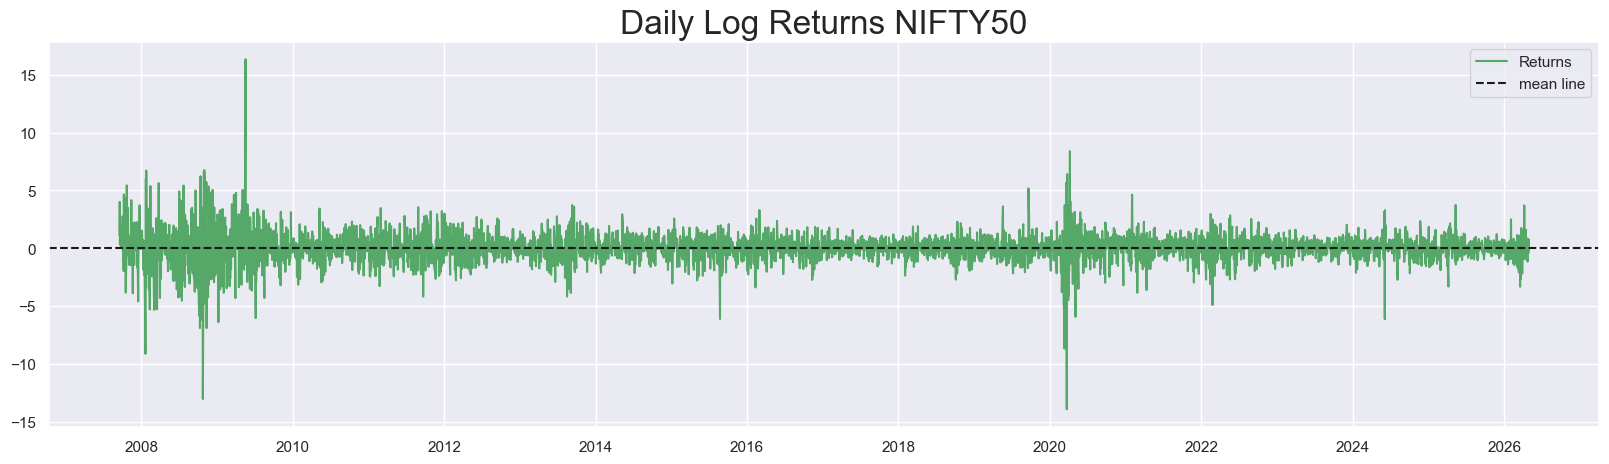

In [27]:
# Plotting the Daily log Returns
plt.figure(figsize=(20,5))
plt.plot(nifty_df.returns[1:],color='g',label='Returns')
plt.axhline(nifty_df.returns.mean(),color='k',linestyle='--',label='mean line')
plt.title("Daily Log Returns NIFTY50",size=24)
plt.legend()
plt.show()

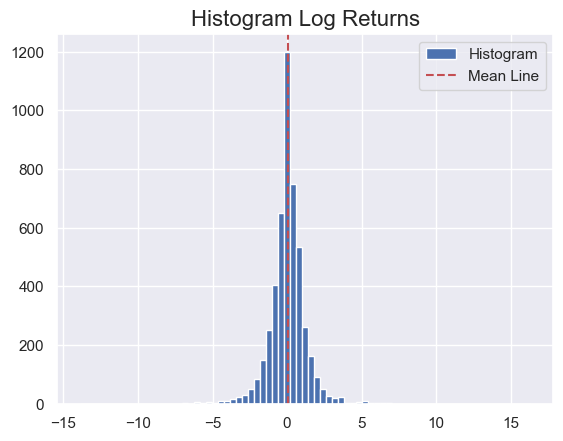

In [28]:
# Histogram 
plt.hist(nifty_df.returns,bins=75,label='Histogram')
plt.axvline(nifty_df.returns.mean(),color='r',linestyle='--',label='Mean Line')
plt.title("Histogram Log Returns",size=16)
plt.legend()
plt.show()


`Clearly this shows that Log Returns of NIFTY50 is Normally distributed`

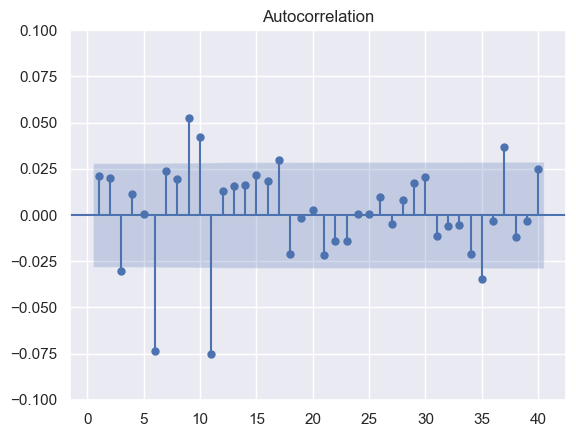

In [29]:
# Checking the Stationarity of Returns
sgt.plot_acf(nifty_df.returns[1:] , zero=False, lags=40)
plt.ylim(-.1,.1)
plt.show()

In [30]:
# Since most of the lags are in significant -> Stationarity 
# Let us Confirm it by ADF Test
t_stats_ret, p_value_ret , *other  = sts.adfuller(nifty_df.returns[1:])

In [31]:
print(f'\tADF TEST ON LOG RETURNS \nT-Statistic = {t_stats_ret} \n P-Value = {p_value_ret}')

	ADF TEST ON LOG RETURNS 
T-Statistic = -21.20173547644791 
 P-Value = 0.0


`We clearly see that p value is <0.05 Thus We can rejec the Null Hypothesis and Thus Log Returns are Stationary`

### Model Training

#### Baseline Models

`(i) Mean Forecast`

In [32]:
train_mean = nifty_train.price.mean()
train_mean

np.float64(8384.608687058713)

In [33]:
mean_forecast = pd.Series(train_mean, index = nifty_test.index)

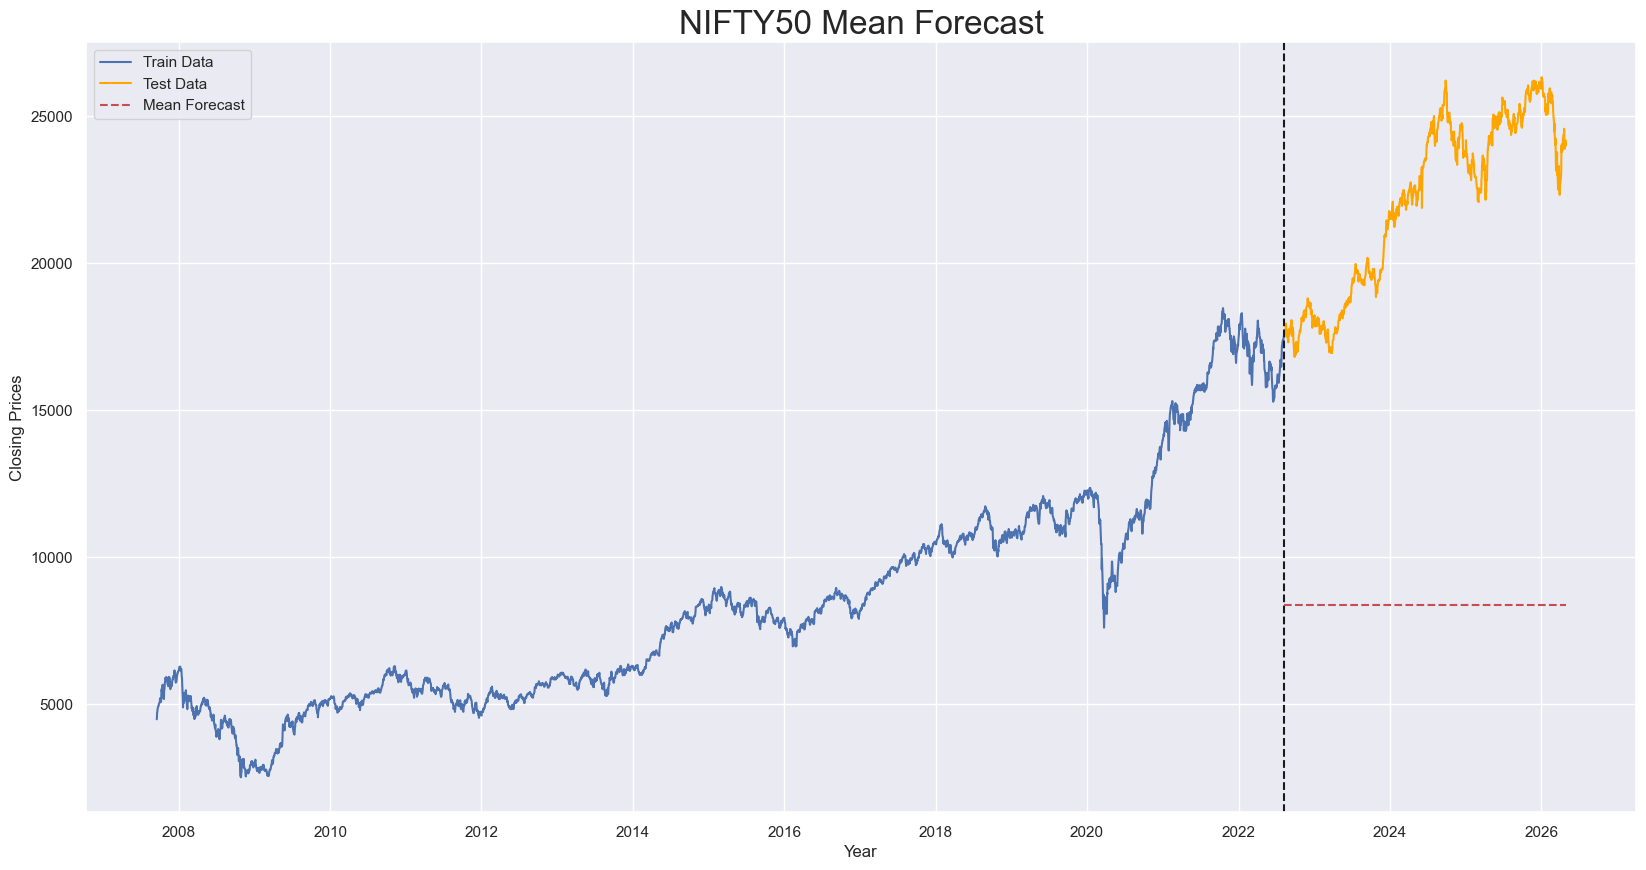

In [34]:
plt.figure(figsize=(20,10))
plt.plot(nifty_train.index , nifty_train.price,color='b',label='Train Data')
plt.plot(nifty_test.index , nifty_test.price,color='orange',label='Test Data')
plt.axvline(nifty_train.index[-1],linestyle="--",color='k')
plt.plot(mean_forecast.index, mean_forecast.values, color='r',linestyle='--',label='Mean Forecast')
plt.title("NIFTY50 Mean Forecast",size=24)
plt.xlabel("Year")
plt.ylabel("Closing Prices")
plt.legend()
plt.show()

In [35]:
# Mean residuals
mean_residual = pd.Series(nifty_test.price - mean_forecast , index = nifty_test.index)

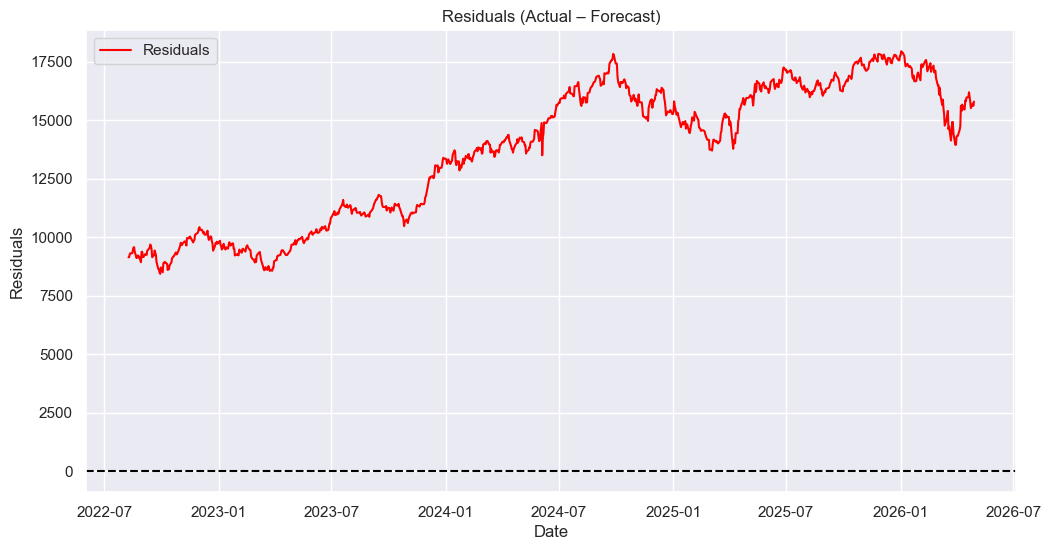

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# residual line
plt.plot(mean_residual, color='red', label='Residuals')

# zero reference line
plt.axhline(y=0, color='black', linestyle='--')

# titles
plt.title("Residuals (Actual – Forecast)")

# labels
plt.xlabel("Date")
plt.ylabel("Residuals")

plt.legend()
plt.show()

`Evaluating MAE, RMSE`

In [37]:
mae = np.mean(abs(nifty_test.price - mean_forecast))
rmse = np.sqrt(np.mean((nifty_test.price - mean_forecast)**2))

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_mean = mean_absolute_error(nifty_test.price, mean_forecast)
rmse_mean = np.sqrt(mean_squared_error(nifty_test.price, mean_forecast))

print("MAE:", mae_mean)
print("RMSE:", rmse_mean)

MAE: 13656.721180080563
RMSE: 13967.579626840823


`Thus We see that Mean Absolute Error and Root Mean Squared Error are very high Thus suggesting the very bad fitting`

`(ii) Naive Model`

`One of the best performing Baseline model, it assumes that the forecast value is nothing but the last recorded data`       
`If we fit the Naive Model on Training data then it assumes a fix value which is the last record of training data`

In [39]:
# last observed value from training
last_value = nifty_train.price.iloc[-1]

# create forecast (constant line)
naive_forecast = pd.Series(last_value, index=nifty_test.index)

#### Plotting Naive Model

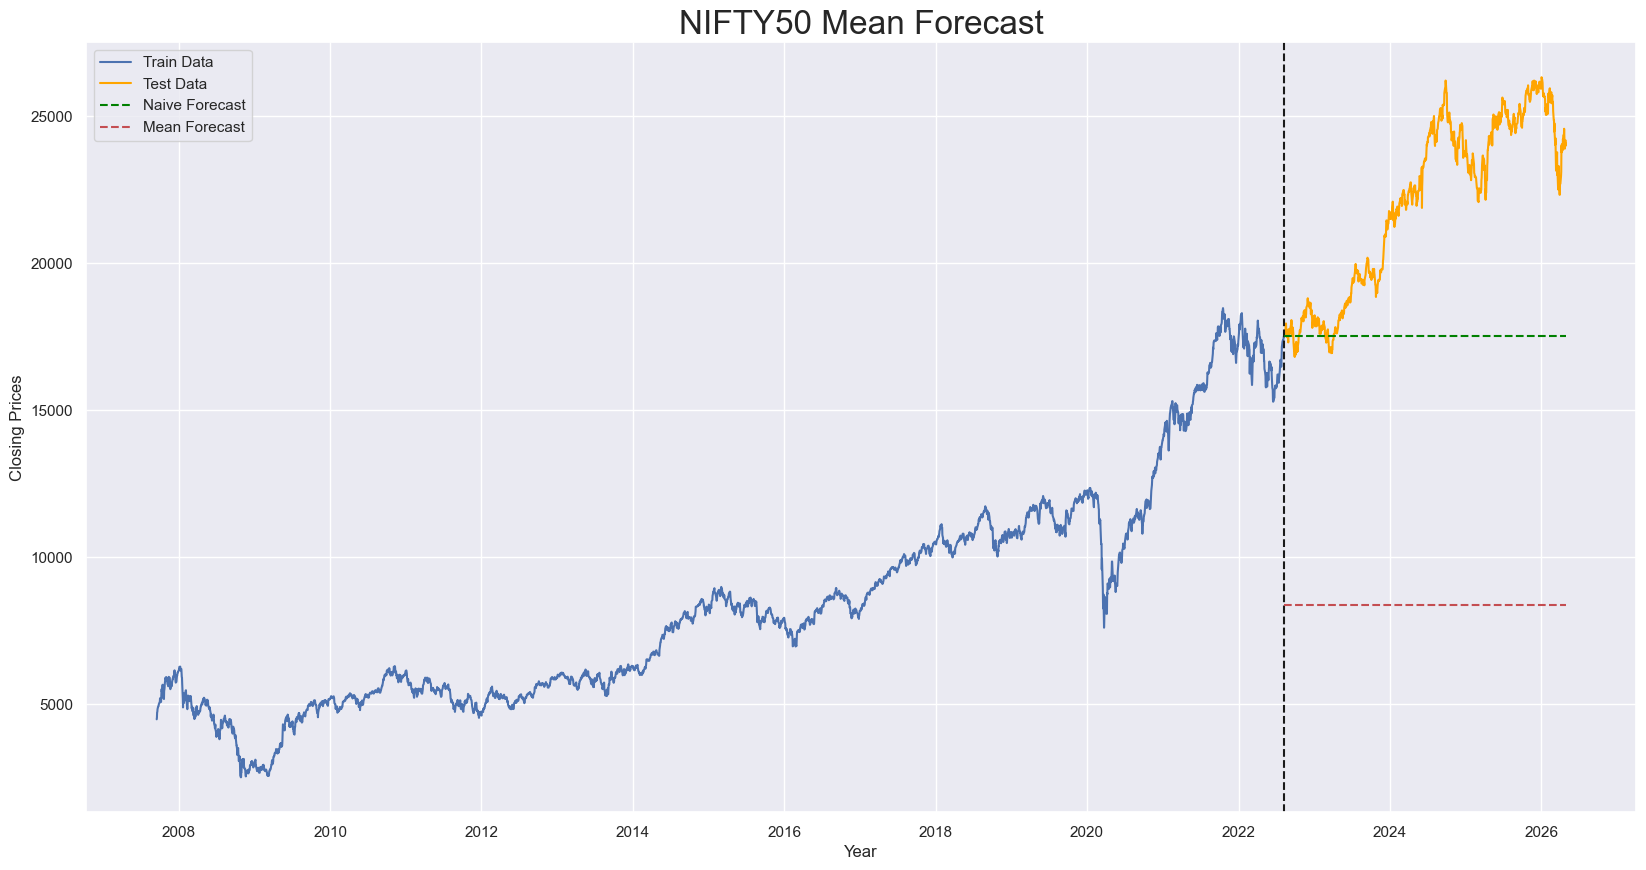

In [40]:
plt.figure(figsize=(20,10))
plt.plot(nifty_train.index , nifty_train.price,color='b',label='Train Data')
plt.plot(nifty_test.index , nifty_test.price,color='orange',label='Test Data')
plt.axvline(nifty_train.index[-1],linestyle="--",color='k')
plt.plot(naive_forecast.index, naive_forecast.values, color='green',linestyle='--',label='Naive Forecast')
plt.plot(mean_forecast.index, mean_forecast.values, color='r',linestyle='--',label='Mean Forecast')
plt.title("NIFTY50 Mean Forecast",size=24)
plt.xlabel("Year")
plt.ylabel("Closing Prices")
plt.legend()
plt.show()

In [41]:
# Residual Series of Naive Model
naive_residual = pd.Series(nifty_test.price - naive_forecast,index = nifty_test.index)

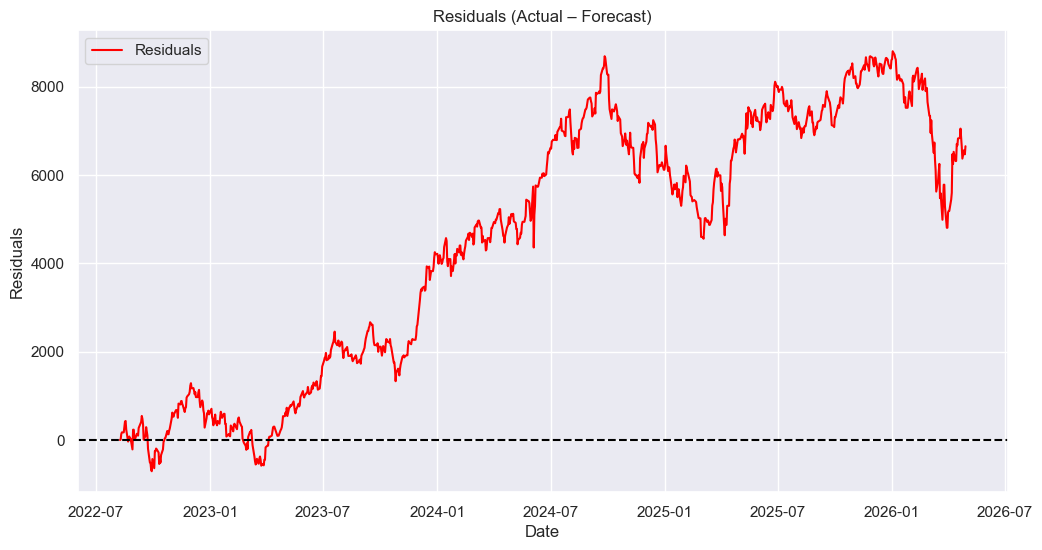

In [42]:
# Plotting Residuals of Naive Model

plt.figure(figsize=(12,6))

# residual line
plt.plot(naive_residual, color='red', label='Residuals')

# zero reference line
plt.axhline(y=0, color='black', linestyle='--')

# titles
plt.title("Residuals (Actual – Forecast)")

# labels
plt.xlabel("Date")
plt.ylabel("Residuals")

plt.legend()
plt.show()

In [43]:
# Evaluating Mean Absolute Error, Root Mean Squared Error

mae_naive = mean_absolute_error(nifty_test.price, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(nifty_test.price, naive_forecast))

print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

MAE: 4547.352950987011
RMSE: 5383.640309569668


In [44]:
# Building a bar Plot which shows Error evaluations of Different Models
mae_errors = [mae_mean,mae_naive]
rmse_errors = [rmse_mean,rmse_naive]
mae_series = pd.Series(mae_errors , index = ['Mean','Naive']).sort_values()
rmse_series = pd.Series(rmse_errors , index = ['Mean','Naive']).sort_values()

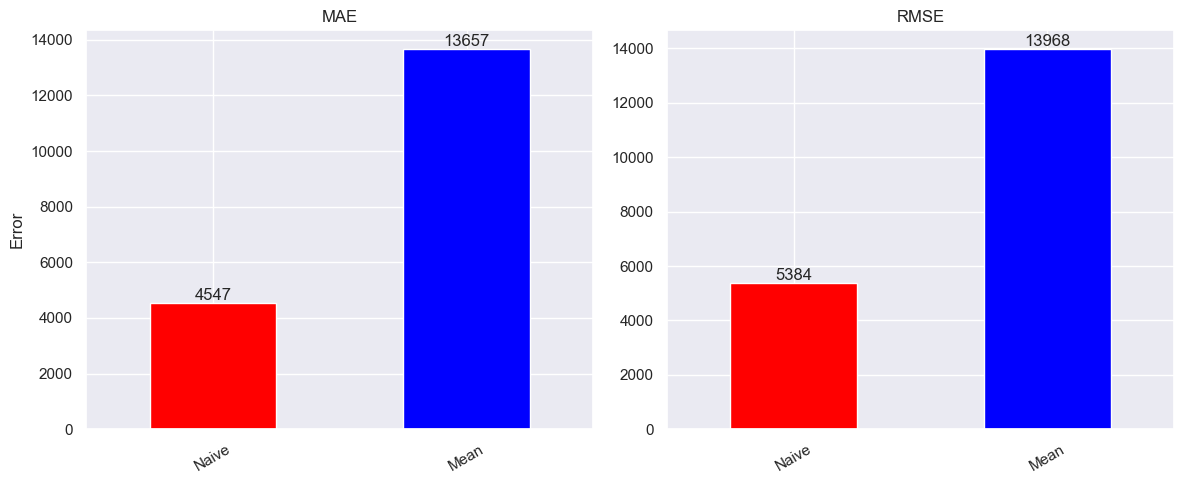

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(12,5))  # 1 row, 2 columns

# ---- MAE plot ----
mae_series.plot(kind='bar', color=['red', 'blue'], ax=axes[0])
axes[0].set_title("MAE")
axes[0].set_ylabel("Error")

for i, v in enumerate(mae_series):
    axes[0].text(i, v, f"{v:.0f}", ha='center', va='bottom')

# ---- RMSE plot ----
rmse_series.plot(kind='bar', color=['red', 'blue'], ax=axes[1])
axes[1].set_title("RMSE")

for i, v in enumerate(rmse_series):
    axes[1].text(i, v, f"{v:.0f}", ha='center', va='bottom')

# common formatting
for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()